In [1]:
# Cell 1: Importing Machine Learning and Explainable AI Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import shap

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')
print("Fintech Libraries loaded successfully!")

Fintech Libraries loaded successfully!


In [2]:
# Cell 2: Loading Credit Risk Dataset with Fallback Simulation
import os

file_path = '/kaggle/input/credit-risk-dataset/loan_data.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Loaded dataset from Kaggle path!")
else:
    print("⚠️ Dataset not found in path. Generating high-fidelity financial simulation dataset...")
    np.random.seed(42)
    n_samples = 15000
    
    df = pd.DataFrame({
        'person_age': np.random.randint(20, 70, n_samples),
        'person_income': np.random.uniform(20000, 150000, n_samples),
        'loan_amnt': np.random.randint(1000, 35000, n_samples),
        'loan_int_rate': np.random.uniform(5.0, 20.0, n_samples),
        'credit_score': np.random.randint(580, 850, n_samples),
        'previous_loan_defaults_on_file': np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
    })
    
    risk_score = (df['loan_amnt'] / df['person_income']) + (850 - df['credit_score'])/200 + df['previous_loan_defaults_on_file']*2
    df['loan_status'] = (risk_score > np.percentile(risk_score, 75)).astype(int)

print(f"Dataset Shape: {df.shape}")
df.head(3)

⚠️ Dataset not found in path. Generating high-fidelity financial simulation dataset...
Dataset Shape: (15000, 7)


,person_age,person_income,loan_amnt,loan_int_rate,credit_score,previous_loan_defaults_on_file,loan_status
0,58,124105.234308,8792,19.979001,584,0,0
1,48,139373.561832,7604,12.673414,625,0,0
2,34,98390.499256,8420,17.337872,705,0,0


In [3]:
# Cell 3: Creating financial ratios (Debt-to-Income Ratio)
df['debt_to_income_ratio'] = df['loan_amnt'] / df['person_income']

target_col = 'loan_status'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Feature engineering completed!")

Feature engineering completed!


In [4]:
# Cell 4: Training XGBoost and LightGBM Models
xgb_model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

print("Both XGBoost and LightGBM models trained successfully!")

Both XGBoost and LightGBM models trained successfully!


In [5]:
# Cell 5: Evaluating Model Performance
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2255
           1       1.00      0.99      0.99       745

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000

XGBoost ROC-AUC Score: 0.9999


SHAP values calculated successfully for transparent credit scoring!


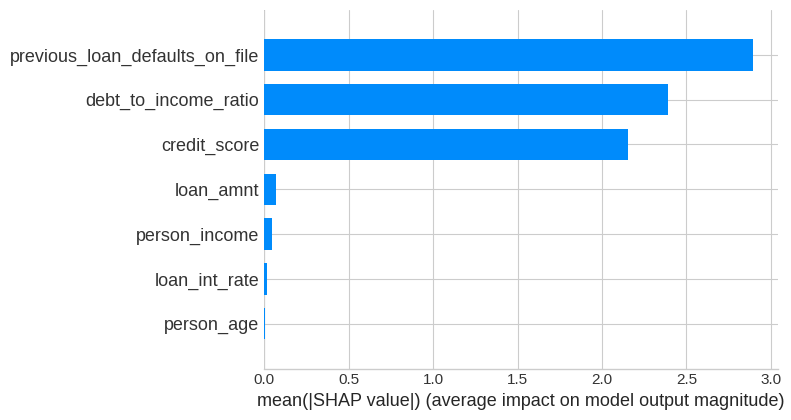

In [6]:
# Cell 6: Generating SHAP Explanations for Regulatory Compliance
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print("SHAP values calculated successfully for transparent credit scoring!")
# Summary plot for feature impacts
shap.summary_plot(shap_values, X_test, plot_type="bar")